In [276]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import math as m
import pyspark.sql.functions as F

# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("MAST30034 Tutorial 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)

In [277]:
# Outlier detection and treatment using IQR altered from https://www.machinelearningplus.com/pyspark/pyspark-outlier-detection-and-treatment/ to handle large datasets
def iqr_outlier_treatment(dataframe, columns, n):
    """
    Detects and treats outliers using IQR for multiple variables in a PySpark DataFrame.
    :param dataframe: The input PySpark DataFrame
    :param columns: A list of columns to apply IQR outlier treatment
    :param factor: The IQR factor to use for detecting outliers (default is 1.5)
    :return: The processed DataFrame with outliers treated
    """
    factor = m.sqrt(np.log(n)) - 0.5  # Adjust the factor based on the number of standard deviations
    for column in columns:
        # Calculate Q1, Q3, and IQR
        quantiles = dataframe.approxQuantile(column, [0.25, 0.75], 0.01)
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        # Define the upper and lower bounds for outliers
        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr
        # Filter outliers and update the DataFrame
        dataframe = dataframe.filter((F.col(column) >= lower_bound) & (F.col(column) <= upper_bound))
    return dataframe

**Creating the Training(Analysis) Data**

In [278]:
sdf_2024_green = spark.read.parquet("../taxi_data/green/2024")

sdf_2024_green = sdf_2024_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

sdf_2024_yellow = spark.read.parquet("../taxi_data/yellow/2024")

sdf_2024_yellow = sdf_2024_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

In [279]:
sdf_2023_green = spark.read.parquet("../taxi_data/green/2023")

sdf_2023_green = sdf_2023_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

sdf_2023_yellow = spark.read.parquet("../taxi_data/yellow/2023")

sdf_2023_yellow = sdf_2023_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")


In [280]:
sdf_2024 = sdf_2024_green.unionByName(sdf_2024_yellow, allowMissingColumns=True)
sdf_2024.count()

41829938

In [281]:
sdf_2023 = sdf_2023_green.unionByName(sdf_2023_yellow, allowMissingColumns=True)
sdf_2023.count()

15610024

In [282]:
# Read the irregular data for 2023 and 2024 in the month of October and removed all the rows with null pickup and dropoff datetimes
temp = spark.read.parquet("../taxi_data/irregular")

temp = temp.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

temp_work = temp.filter(F.col("pickup_datetime").isNotNull() & F.col("dropoff_datetime").isNotNull()) \
    .filter(F.col("pickup_datetime") < F.col("dropoff_datetime"))

sdf_2023 = sdf_2023.unionByName(temp_work, allowMissingColumns=True)

sdf_2023.count()

15676112

In [283]:
sdf_train = sdf_2023.unionByName(sdf_2024, allowMissingColumns=True)
sdf_train.count()

57506050

**Creating Test Data**

In [284]:
sdf_2025_green = spark.read.parquet("../taxi_data/green/2025")

sdf_2025_green = sdf_2025_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee", "cbd_congestion_fee")

sdf_2025_yellow = spark.read.parquet("../taxi_data/yellow/2025")

sdf_2025_yellow = sdf_2025_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee", "cbd_congestion_fee")

In [285]:
sdf_2025 = sdf_2025_green.unionByName(sdf_2025_yellow, allowMissingColumns=True)
sdf_2025.count()

24386791

**Preprocessing for Train Data**

In [288]:
# Calculate travel time in seconds
sdf_train = sdf_train.withColumn("travel_time_seconds",\
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")))
# filtering the data for valid trips
# travel time should be greater than  or equal to 3 minutes (180 seconds) and less than or equal to 5 hours (18000 seconds) 
# trip distance should be greater than 1 mile as it is reasonable to assume that a taxi ride should cover some distance more than a mile to be stuck in traffic and be worth it
# fare amount should be greater than 3 dollars and total amount should be greater than 3 dollars as according to the NYC Taxi and Limousine Commission,\
#  the initial fare for a taxi ride is $3.00
sdf_train_filtered = sdf_train.filter((F.col("travel_time_seconds") >= 180) & (F.col("trip_distance") > 1) & (F.col("fare_amount") > 3) & (F.col("total_amount") > 3) \
    & (F.col("travel_time_seconds") <= 18000))

# congestion surcharge should be greater than or equal to 0 and not null as according to https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
sdf_train_filtered = sdf_train_filtered.withColumn("congestion_surcharge",\
    F.when((F.col("congestion_surcharge").isNotNull()) & ~(F.isnan("congestion_surcharge")), F.col("congestion_surcharge")).otherwise(0))

# Checking NaN or null values in the dataframe
# adapted from https://sparkbyexamples.com/pyspark/pyspark-find-count-of-null-none-nan-values/
from pyspark.sql.functions import col,isnan, when, count
sdf_train_filtered.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in sdf_train_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

sdf_train_filtered_outlier = iqr_outlier_treatment(sdf_train_filtered, ["travel_time_seconds", "trip_distance"], n = sdf_train_filtered.count())
sdf_train_filtered_outlier.orderBy("trip_distance", ascending=False).show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+
|       2|2023-08-11 17:11:50|2023-08-11 18:01:18|          43|         130|        14.52|       63.9|       0.0|       74.45|                 0.0|               2968|
|       2|2024-01-05 19:44:48|2024-01-05 20:17:57|         132|          64|        14.52|       56.2|       0.0|       61.95|                 0.0|               1989|
|       2|2024-02-05 19:24:32|2024-02-05 19:52:13|         138|         141|        14.52|       56.2|     15.28|       91.67|                 2.5|             

In [289]:
sdf_train_filtered_outlier.count()

39642599

In [ ]:
# average new york taxi speed according to https://medium.com/@jiaminhan/looking-through-the-taxi-meter-analysis-of-the-nyc-green-taxi-data-c1dbe5619afe
average_speed = 14 / 3600 # in miles per second

# average time spent in traffic  per day in new york according to https://congestionreliefzone.mta.info/about
average_time_in_traffic = m.floor((117/365) * 3600) # in seconds

# tolerance time for congestion time
tolerance = 120

sdf_train_filtered_outlier = sdf_train_filtered_outlier.withColumn("congestion_time_seconds",\
    F.when((F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed) > tolerance),\
    (F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed))).otherwise(0))

39642599

In [293]:
sdf_train_filtered_outlier.orderBy("congestion_time_seconds", ascending=False).show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+-----------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|congestion_time_seconds|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+-----------------------+
|       2|2024-08-22 01:19:21|2024-08-22 02:33:10|         170|         230|         1.06|        6.5|       0.0|        11.5|                 2.5|               4429|      4156.428571428572|
|       2|2023-09-08 18:49:29|2023-09-08 20:03:15|          82|         158|         1.05|       63.9|     15.47|       92.81|                 2.5|               4426|                 4156.0|
|       1|2024-10-21 15:03:18|2024-10-21

In [294]:
# filtering out rows where congestion time is less than 0 to find trips that were in congestion
final_filtered_df = sdf_train_filtered_outlier.filter(F.col("congestion_time_seconds") > 0)
final_filtered_df.count()

26021194

**Preprocessing for Test Data**

In [301]:
# Calculate travel time in seconds
sdf_2025 = sdf_2025.withColumn("travel_time_seconds",\
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")))
# filtering the data for valid trips
# travel time should be greater than  or equal to 3 minutes (180 seconds) and less than or equal to 5 hours (18000 seconds) 
# trip distance should be greater than 1 mile as it is reasonable to assume that a taxi ride should cover some distance more than a mile to be stuck in traffic and be worth it
# fare amount should be greater than 3 dollars and total amount should be greater than 3 dollars as according to the NYC Taxi and Limousine Commission,\
#  the initial fare for a taxi ride is $3.00
sdf_2025_filtered = sdf_2025.filter((F.col("travel_time_seconds") >= 180) & (F.col("trip_distance") > 1) & (F.col("fare_amount") > 3) & (F.col("total_amount") > 3) \
    & (F.col("travel_time_seconds") <= 18000))

# congestion surcharge should be greater than or equal to 0 and not null as according to https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
sdf_2025_filtered = sdf_2025_filtered.withColumn("congestion_surcharge",\
    F.when((F.col("congestion_surcharge").isNotNull()) & ~(F.isnan("congestion_surcharge")), F.col("congestion_surcharge")).otherwise(0))

# Checking NaN or null values in the dataframe
# adapted from https://sparkbyexamples.com/pyspark/pyspark-find-count-of-null-none-nan-values/
sdf_2025_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_2025_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

sdf_2025_filtered_outlier = iqr_outlier_treatment(sdf_2025_filtered, ["travel_time_seconds", "trip_distance"], n = sdf_2025_filtered.count())
sdf_2025_filtered_outlier.orderBy("trip_distance", ascending=False).show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+
|       2|2025-02-01 19:58:38|2025-02-01 20:30:05|          80|          18|        14.15|       56.2|       0.0|       64.64|                 0.0|               1887|
|       2|2025-02-24 15:37:41|2025-02-24 16:23:44|         132|           7|        14.15|       59.7|     13.09|       78.54|                 0.0|               2763|
|       2|2025-05-21 23:22:10|2025-05-22 00:06:28|         144|         200|        14.15|       64.6|      10.0|       83.53|                 2.5|             

In [302]:
sdf_2025_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_2025_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

VendorID,PULocationID,DOLocationID,trip_distance,fare_amount,tip_amount,total_amount,congestion_surcharge,travel_time_seconds
0,0,0,0,0,0,0,0,0


In [303]:
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.withColumn("congestion_time_seconds",\
    F.when((F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed) > tolerance),\
    (F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed))).otherwise(0))

sdf_2025_filtered_outlier.show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+-----------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|congestion_time_seconds|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+-----------------------+
|       2|2025-05-01 00:17:04|2025-05-01 00:56:06|          25|         216|         9.34|       44.3|       0.0|        46.8|                 0.0|               2342|                    0.0|
|       2|2025-05-01 00:56:16|2025-05-01 01:10:26|         160|         129|         2.95|       16.3|       0.0|        18.8|                 0.0|                850|                    0.0|
|       1|2025-05-01 00:24:49|2025-05-01

In [304]:
final_filtered_testdf = sdf_2025_filtered_outlier.filter(F.col("congestion_time_seconds") > 0)

**Data Analysis**

In [222]:
from pyspark.sql import functions as F
# Calculate median congestion time and total trips for each DOLocationID
# median used because of obvious skewness in the data (see histogram below)
congestion_groupby = final_filtered_df.groupBy("DOLocationID").agg(F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.count("DOLocationID").alias("total_trips"))

congestion_groupby.orderBy("median_congestion_time_seconds", ascending=False).show(10)


+------------+------------------------------+-----------+
|DOLocationID|median_congestion_time_seconds|total_trips|
+------------+------------------------------+-----------+
|         204|            2151.5714285714284|          1|
|         105|             952.8571428571428|          9|
|         156|             866.5714285714284|          3|
|          46|             837.1428571428573|         57|
|         214|             749.5714285714284|         15|
|           5|             743.5714285714284|          4|
|         222|             724.2857142857142|       2618|
|          55|             673.2857142857142|       2593|
|          26|             644.1428571428571|       4074|
|          27|             643.8571428571429|         34|
+------------+------------------------------+-----------+
only showing top 10 rows



In [318]:
# add a column to the dataframe
sum_total_trips = congestion_groupby.select(F.sum("total_trips").alias("sum_total_trips")).collect()[0]["sum_total_trips"]

congestion_groupby = congestion_groupby.withColumn("proportion_of_congestion_time",\
    F.col("median_congestion_time_seconds") * (F.col("total_trips") / sum_total_trips))

congestion_groupby = congestion_groupby.withColumnRenamed("DOLocationID", "LocationID")
congestion_groupby.orderBy("proportion_of_congestion_time", ascending=False).show(10)

# This shows LocationID 230 (time square) has the highest proportion of congestion time in NYC taxi rides in 2023 and 2024

+----------+------------------------------+-----------+-----------------------------+
|LocationID|median_congestion_time_seconds|total_trips|proportion_of_congestion_time|
+----------+------------------------------+-----------+-----------------------------+
|       161|             483.1428571428571|    1088470|           20.209929863875026|
|       230|             537.7142857142857|     849730|           17.559223454542476|
|       237|             366.2857142857143|    1074193|           15.120810762400613|
|       236|             328.1428571428571|    1093819|           13.793713380605933|
|       170|                         411.0|     805207|           12.718097294074976|
|       163|            445.85714285714283|     741807|           12.710406354582673|
|       162|             420.1428571428571|     781996|           12.626247424091519|
|        48|             451.2857142857143|     678974|           11.775449911000571|
|       186|                         458.0|     667837

In [224]:
import geopandas as gpd

# Load the shapefile (use the .shp file as entry point)
sf = gpd.read_file("../taxi_data/taxi_zones/taxi_zones.shp")
sf.head()

# Convert the geometry shape to to latitude and longitude
# Please attribute this if you are using it
sf['geometry'] = sf['geometry'].to_crs("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs")
sf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


In [225]:
zones = pd.read_csv("../taxi_data/taxi_zones/taxi_zone_lookup.csv")
zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [226]:
zones_df = gpd.GeoDataFrame(
    pd.merge(zones, sf, on='LocationID', how='inner')
)
zones_df['geometry'].type


0           Polygon
1      MultiPolygon
2           Polygon
3           Polygon
4           Polygon
           ...     
258         Polygon
259         Polygon
260         Polygon
261    MultiPolygon
262         Polygon
Length: 263, dtype: object

In [227]:
congestion_groupby_pd = congestion_groupby.toPandas()
congestion_geodata = congestion_groupby_pd.merge(zones_df[['LocationID', 'geometry']], on='LocationID', how='inner')
congestion_geodata.head()

,LocationID,median_congestion_time_seconds,total_trips,proportion_of_congestion_time,geometry
0,148,404.285714,340886,5.296273,"POLYGON ((-73.98448 40.72023, -73.98507 40.719..."
1,243,407.285714,14254,0.223105,"POLYGON ((-73.93157 40.86958, -73.93141 40.868..."
2,31,468.571429,286,0.005150,"POLYGON ((-73.87094 40.85727, -73.87094 40.857..."
3,85,556.428571,4814,0.102941,"POLYGON ((-73.94716 40.65559, -73.94703 40.654..."
4,137,357.142857,331937,4.555860,"POLYGON ((-73.9722 40.7404, -73.97222 40.74031..."


In [228]:
# create a JSON 
geoJSON = zones_df[['LocationID', 'geometry']].drop_duplicates('LocationID').to_json()

In [254]:
import folium

map_1 = folium.Map(
    location=[40.66, -73.94],
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}{r}.png",
    attr='Map tiles by <a href="https://stamen.com/">Stamen Design</a>, '
         '<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
    zoom_start=10
)

# refer to the folium documentations on how to plot aggregated data.
map_1.add_child(folium.Choropleth(
    geo_data=geoJSON, # geoJSON 
    name='choropleth', # name of plot
    data=congestion_geodata.reset_index(), # data source
    columns=['LocationID','median_congestion_time_seconds'], # the columns required
    key_on='properties.LocationID', # this is from the geoJSON's properties
    fill_color='YlOrRd', # color scheme
    nan_fill_color='black',
    legend_name='Median Congestion Time (seconds)'
))

map_1.save('../plots/foliumChoroplethMap1.html')

map_2 = folium.Map(
    location=[40.66, -73.94],
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}{r}.png",
    attr='Map tiles by <a href="https://stamen.com/">Stamen Design</a>, '
         '<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
    zoom_start=10
)

# refer to the folium documentations on how to plot aggregated data.
map_2.add_child(folium.Choropleth(
    geo_data=geoJSON, # geoJSON 
    name='choropleth', # name of plot
    data=congestion_geodata.reset_index(), # data source
    columns=['LocationID','proportion_of_congestion_time'], # the columns required
    key_on='properties.LocationID', # this is from the geoJSON's properties
    fill_color='YlOrRd', # color scheme
    nan_fill_color='black',
    legend_name='Proportion of Congestion Time'\
))

map_2.save('../plots/foliumChoroplethMap2.html')

In [230]:
final_filtered_df.show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+-----------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|congestion_time_seconds|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+-----------------------+
|       2|2023-08-31 23:57:20|2023-09-01 00:05:51|          82|         129|         1.32|       10.0|       0.0|        12.5|                 0.0|                511|     171.57142857142856|
|       2|2023-09-01 00:33:26|2023-09-01 00:47:39|          74|         151|         2.46|       15.6|      3.62|       21.72|                 0.0|                853|     220.42857142857144|
|       2|2023-08-31 23:59:18|2023-09-01

In [306]:
# Sample 10% of the final filtered DataFrame for further analysis without stratification
final_filtered_df_pd = final_filtered_df.sample(fraction=0.1, seed=23).toPandas()
final_filtered_testdf_pd = final_filtered_testdf.sample(fraction=0.1, seed=23).toPandas()

final_filtered_df_pd.shape, final_filtered_testdf_pd.shape

((2600439, 12), (1033198, 12))

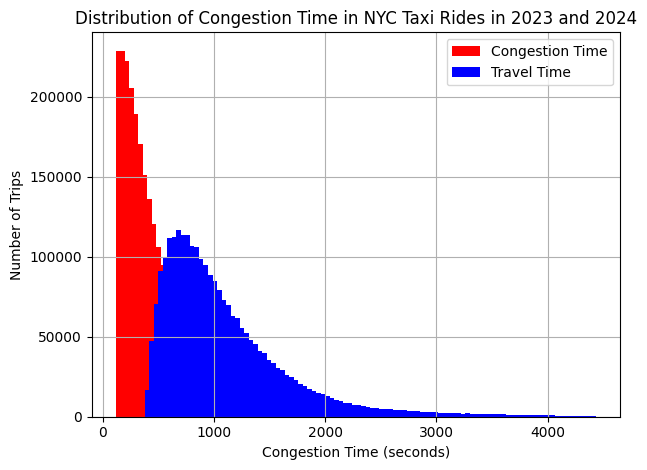

In [307]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
final_filtered_df_pd['congestion_time_seconds'].hist(ax=ax, bins = 100, color='red')
final_filtered_df_pd['travel_time_seconds'].hist(ax=ax, bins = 100, color='blue')
xlabel = "Congestion Time (seconds)"
ax.set_xlabel(xlabel)
ylabel = "Number of Trips"
ax.set_ylabel(ylabel)
title = "Distribution of Congestion Time in NYC Taxi Rides in 2023 and 2024"
ax.set_title(title)
ax.legend(['Congestion Time', 'Travel Time'])
plt.tight_layout()  
plt.show()

In [308]:
%pip install utilsforecast

Note: you may need to restart the kernel to use updated packages.


In [309]:
congestion_geodata["proportion_of_congestion_time"].sort_values(ascending=False).head(10)

129    20.209930
38     17.559223
170    15.120811
25     13.793713
205    12.718097
83     12.710406
133    12.626247
80     11.775450
239    11.754624
211    11.395130
Name: proportion_of_congestion_time, dtype: float64

In [310]:
final_filtered_df_pd.groupby("DOLocationID").size().sort_values(ascending=False).head(10)

DOLocationID
236    109167
161    108731
237    107803
230     84808
142     83670
170     80691
162     78117
68      77012
239     74711
163     74521
dtype: int64

In [311]:
final_filtered_df_pd.sort_values(by="congestion_time_seconds", ascending=False).head(10)

,VendorID,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,tip_amount,total_amount,congestion_surcharge,travel_time_seconds,congestion_time_seconds
707348,2,2024-06-10 16:27:34,2024-06-10 17:41:11,166,132,1.08,70.00,25.03,108.47,0.0,4417,4139.285714
2099620,1,2024-07-07 14:11:53,2024-07-07 15:25:11,51,51,1.20,17.50,0.00,18.00,0.0,4398,4089.428571
2573864,2,2024-01-26 21:25:48,2024-01-26 22:38:54,114,264,1.23,12.80,0.00,17.80,2.5,4386,4069.714286
323246,2,2023-11-19 12:38:18,2023-11-19 13:51:49,164,230,1.37,12.80,3.36,20.16,2.5,4411,4058.714286
1667466,1,2024-03-15 05:30:00,2024-03-15 06:42:06,193,141,1.10,46.50,0.00,48.00,0.0,4326,4043.142857
466138,2,2023-09-20 15:13:24,2023-09-20 16:26:11,230,43,1.41,54.10,11.62,69.72,2.5,4367,4004.428571
608273,2,2023-12-28 11:56:04,2023-12-28 13:08:54,229,161,1.49,51.30,0.00,55.30,2.5,4370,3986.857143
1245579,2,2024-12-10 15:05:36,2024-12-10 16:18:42,114,230,1.56,38.57,0.00,42.57,0.0,4386,3984.857143
2527872,2,2024-01-16 10:52:39,2024-01-16 12:05:54,237,170,1.63,24.70,0.80,29.50,2.5,4395,3975.857143
1952252,1,2024-04-07 09:13:46,2024-04-07 10:27:15,259,140,1.70,43.50,0.00,45.00,0.0,4409,3971.857143


In [312]:
unique_ids = [161, 230, 237, 236, 170, 163]

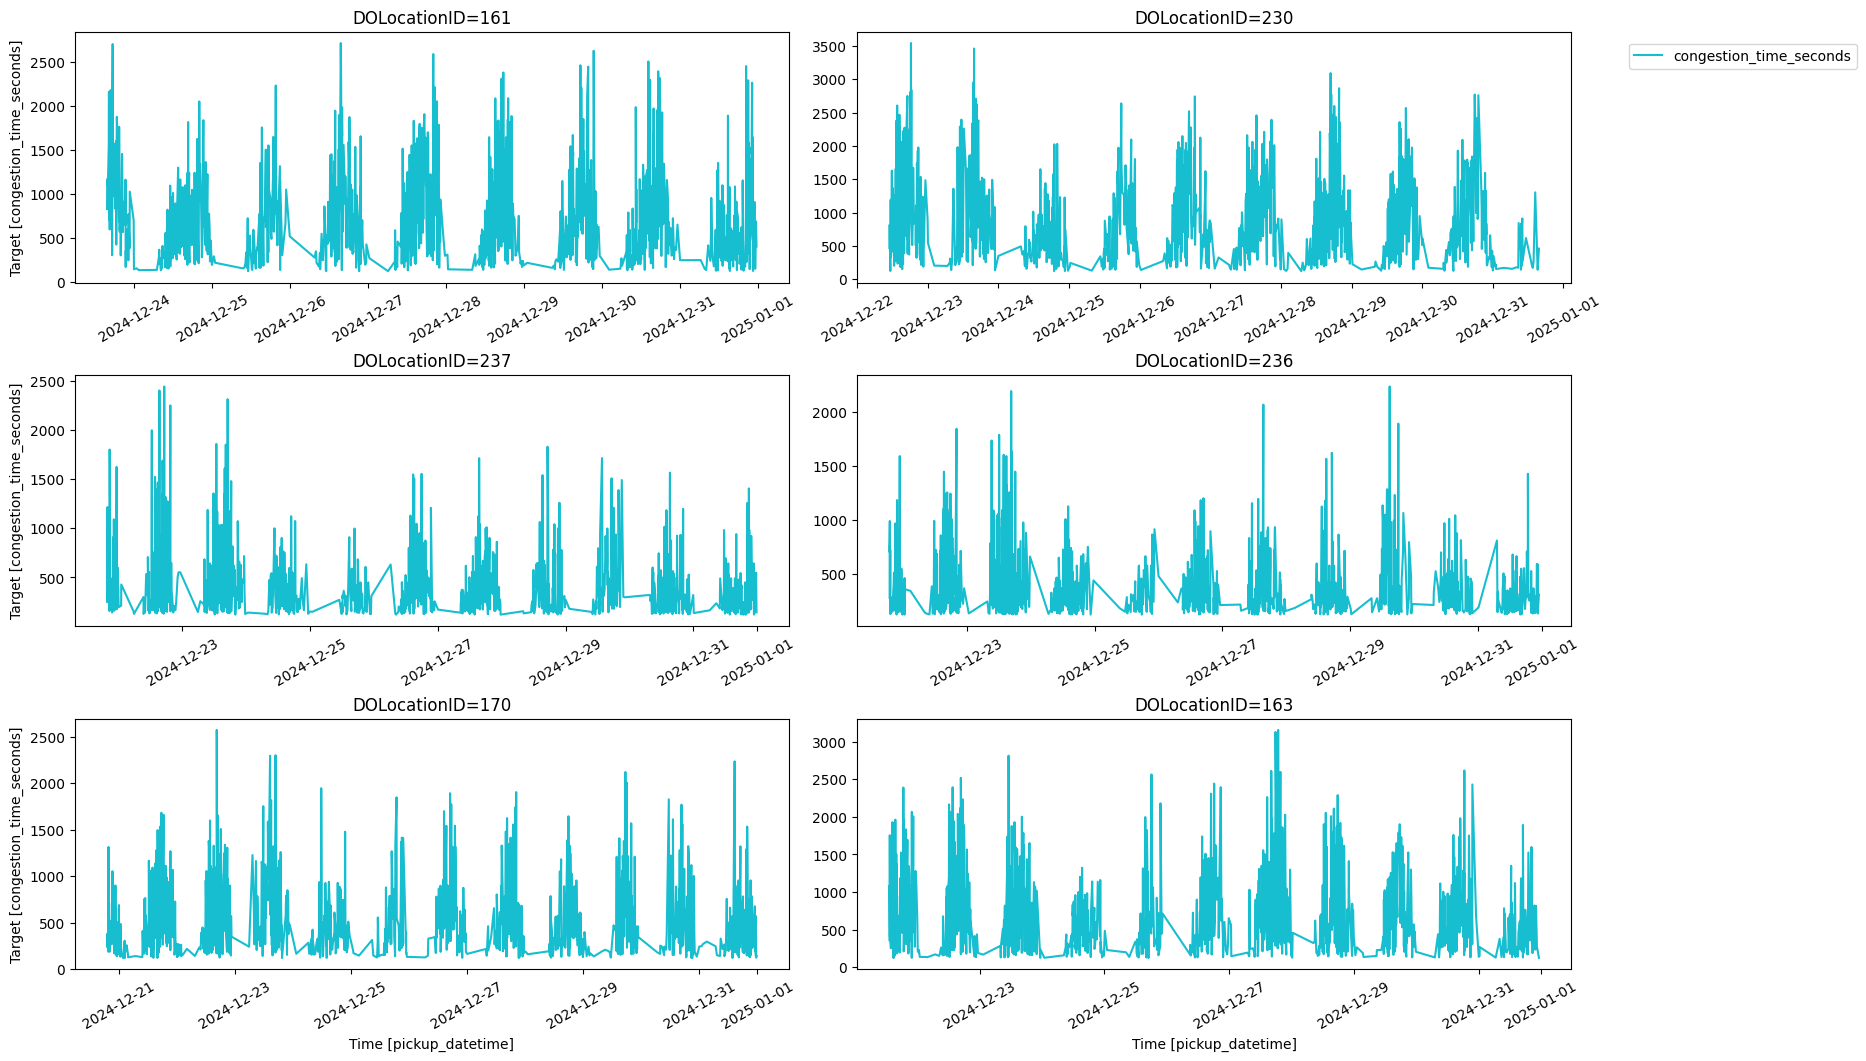

In [329]:
from utilsforecast.plotting import plot_series
#number of months
n = 1/4
plot_series(df=final_filtered_df_pd,
            ids =unique_ids, 
            time_col='pickup_datetime',
            target_col='congestion_time_seconds',
            id_col="DOLocationID",
            max_insample_length=n*5000)

# max_insample_length = 500
# This is about 3-4 days of data for the LocationIDs in the unique_ids list 
# max_insample_length = 5000
# This would be about 30-40 days of data for the LocationIDs in the unique_ids list so around a month of data


In [314]:
%pip install statsforecast

Note: you may need to restart the kernel to use updated packages.


In [316]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [321]:
# training only on the LocationIDs in the unique_ids list because the data is too large to train on all the LocationIDs
# this list contrains the LocationIDs with the highest proportion of congestion time in NYC taxi rides in 2023 and 2024

train_data_subset = final_filtered_df_pd[final_filtered_df_pd["DOLocationID"].isin(unique_ids)]
test_data_subset = final_filtered_testdf_pd[final_filtered_testdf_pd["DOLocationID"].isin(unique_ids)]
train_data_subset.shape, test_data_subset.shape

((565721, 12), (218568, 12))

In [ ]:
from sklearn.model_selection import train_test_split

train_data, validation_data = train_test_split(data_subset, train_size=0.7, random_state=23,stratify=data_subset["DOLocationID"])

((396004, 12), (169717, 12))

In [ ]:
from statsforecast.models import AutoARIMA
# There is roughly a daily cycle in the congestion time in NYC taxi rides, so we can use a seasonal ARIMA model
# The season_length is set to 5000/30 because there are about 5000 data points in a month and we want to capture the monthly seasonality
models = [
    AutoARIMA(seasonal=False, alias="AutoARIMA"),
    
    AutoARIMA(season_length = 5000/30, alias="SARIMA"),
]

sf = StatsForecast(
    models=models,
    freq="D",
)
sf.fit(df=train_data)
arima_preds = sf.predict(horizon=5000*5) # predicting for 5 months ahead

arima_eval_df = pd.merge